# Task: Linear vs Polynomial Regression

## Objective
Build and compare Linear Regression and Polynomial Regression models then select the best performing model and interpret its learned equation.


## Dataset
Use the **Boston Housing dataset**.
    
    from sklearn.datasets import load_boston

In [56]:
import pandas as pd
from sklearn.datasets import fetch_openml

boston = fetch_openml(name="boston", as_frame=True)

X = boston.data
y = boston.target

# Combine into one DataFrame for easier exploration
df = pd.concat([X, y.rename("PRICE")], axis=1)

X = X.astype(float)
y = y.astype(float)

/usr/local/lib/python3.12/dist-packages/sklearn/datasets/_openml.py:323: UserWarning: Multiple active versions of the dataset matching the name boston exist. Versions may be fundamentally different, returning version 1. Available versions:
- version 1, status: active
  url: https://www.openml.org/search?type=data&id=531
- version 2, status: active
  url: https://www.openml.org/search?type=data&id=853

  warn(warning_msg)


In [57]:
print("Shape:", df.shape)

Shape: (506, 14)


In [58]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [59]:
df.sample(5)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
298,0.06466,70.0,2.24,0,0.400,6.345,20.1,7.8278,5,358.0,14.8,368.24,4.97,22.5
467,4.42228,0.0,18.10,0,0.584,6.003,94.5,2.5403,24,666.0,20.2,331.29,21.32,19.1
111,0.10084,0.0,10.01,0,0.547,6.715,81.6,2.6775,6,432.0,17.8,395.59,10.16,22.8
26,0.67191,0.0,8.14,0,0.538,5.813,90.3,4.6820,4,307.0,21.0,376.88,14.81,16.6
274,0.05644,40.0,6.41,1,0.447,6.758,32.9,4.0776,4,254.0,17.6,396.90,3.53,32.4


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   CRIM     506 non-null    float64 
 1   ZN       506 non-null    float64 
 2   INDUS    506 non-null    float64 
 3   CHAS     506 non-null    category
 4   NOX      506 non-null    float64 
 5   RM       506 non-null    float64 
 6   AGE      506 non-null    float64 
 7   DIS      506 non-null    float64 
 8   RAD      506 non-null    category
 9   TAX      506 non-null    float64 
 10  PTRATIO  506 non-null    float64 
 11  B        506 non-null    float64 
 12  LSTAT    506 non-null    float64 
 13  PRICE    506 non-null    float64 
dtypes: category(2), float64(12)
memory usage: 49.0 KB


In [61]:
df.describe()

,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,TAX,PTRATIO,B,LSTAT,PRICE
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.554695,6.284634,68.574901,3.795043,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.115878,0.702617,28.148861,2.105710,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.385000,3.561000,2.900000,1.129600,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.449000,5.885500,45.025000,2.100175,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.538000,6.208500,77.500000,3.207450,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.624000,6.623500,94.075000,5.188425,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,0.871000,8.780000,100.000000,12.126500,711.000000,22.000000,396.900000,37.970000,50.000000


In [62]:
df.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


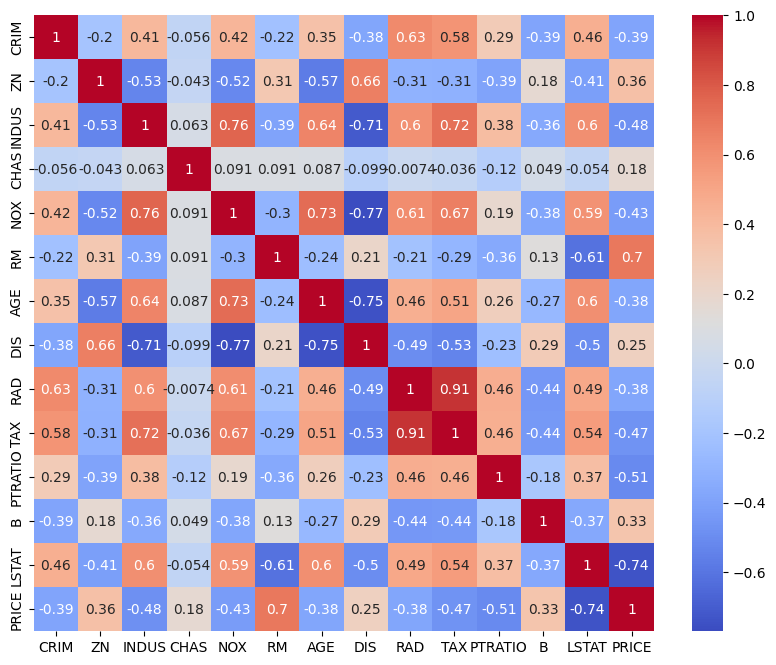

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

The dataset consists of 506 samples and 14 columns, where 13 columns represent input features and one column (PRICE) represents the target variable.
All features are numerical, with CHAS being a binary variable.

The dataset includes various socio-economic and environmental factors such as crime rate (CRIM), number of rooms (RM), and percentage of lower-status population (LSTAT).

Initial observation shows that features have significantly different scales, which may require normalization.

Additionally, some relationships can already be observed: houses with more rooms (RM) tend to have higher prices, while higher values of LSTAT are associated with lower prices.


### 1. Data Preparation

In [64]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [65]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

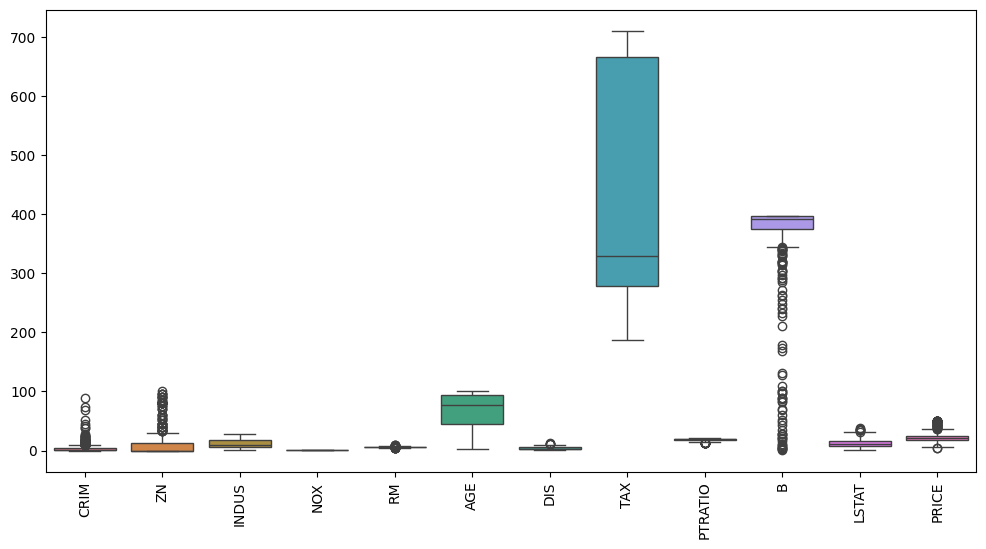

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

In [67]:
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (404, 13)
Test set shape: (102, 13)


### 2. Linear Regression Model
- Train a Linear Regression model
- Make predictions on the test set
- Compute evaluation metrics:
  - MAE
  - MSE
  - RMSE

In [68]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [69]:

# Train model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)


LinearRegression()

In [70]:
# 3. Make predictions
y_pred = lr_model.predict(X_test)

In [71]:
# 4. Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# 5. Print results
print("Linear Regression Results:")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)

Linear Regression Results:
MAE : 3.189091965887837
MSE : 24.291119474973478
RMSE: 4.928602182665332


The Linear Regression model achieved a Mean Absolute Error (MAE) of 3.19 and a Root Mean Squared Error (RMSE) of 4.93. This indicates that, on average, the model’s predictions deviate from the actual house prices by approximately $3,190 to $4,930. While the model captures general trends in the data, the error suggests that there may be nonlinear relationships that Linear Regression cannot fully capture.

### 3. Polynomial Regression Model
- Train a Polynomial Regression model
- Make predictions on the test set
- Compute evaluation metrics:
  - MAE
  - MSE
  - RMSE


In [72]:
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [73]:
degree = 2

poly_model = Pipeline([
    ("poly_features", PolynomialFeatures(degree=degree, include_bias=False)),
    ("linear_regression", LinearRegression())
])

In [74]:
poly_model.fit(X_train, y_train)

Pipeline(steps=[('poly_features', PolynomialFeatures(include_bias=False)),
                ('linear_regression', LinearRegression())])

In [75]:
y_pred_poly = poly_model.predict(X_test)

In [76]:
mae_poly = mean_absolute_error(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)

print("Polynomial Regression Results:")
print("MAE :", mae_poly)
print("MSE :", mse_poly)
print("RMSE:", rmse_poly)

Polynomial Regression Results:
MAE : 2.574835626725908
MSE : 14.257338169992014
RMSE: 3.7758890568966685


### 4. Model Comparison
- Compare Linear vs Polynomial Regression results
- Identify which model performs better on the test data and justify your decision


**Linear Regression: Actual vs Predicted**

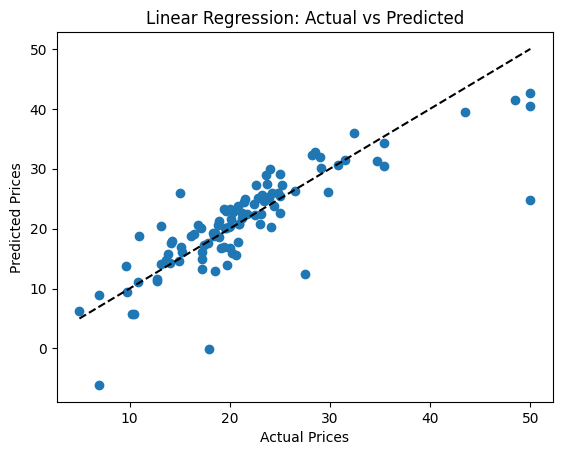

In [77]:
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='black', linestyle='--')

plt.title("Linear Regression: Actual vs Predicted")
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.show()

**Polynomial Regression: Actual vs Predicted**

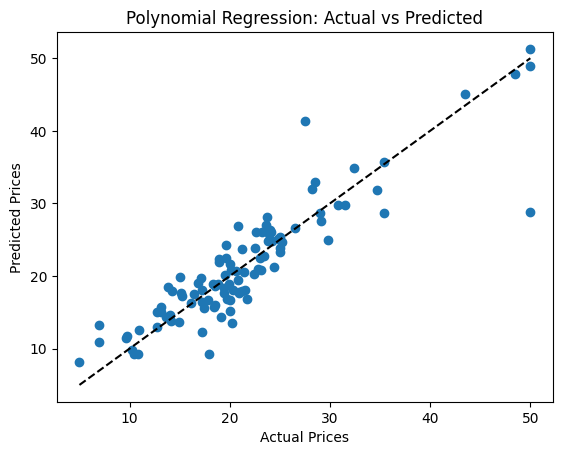

In [78]:
plt.figure()

plt.scatter(y_test, y_pred_poly)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='black', linestyle='--')

plt.title("Polynomial Regression: Actual vs Predicted")
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.show()

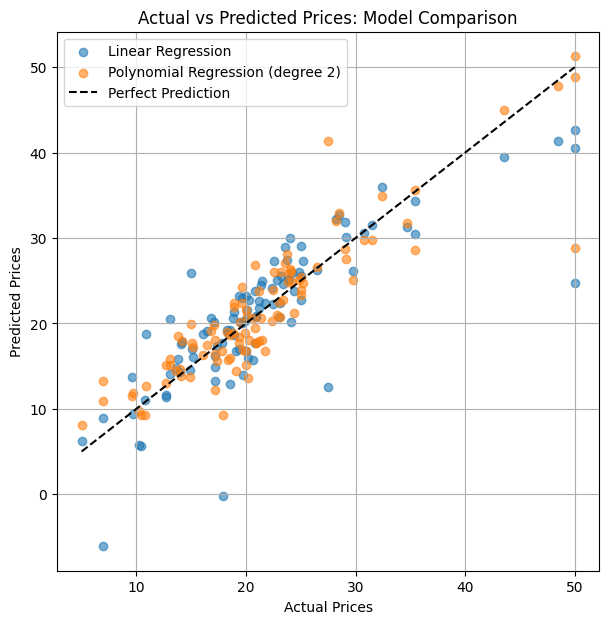

In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

# Linear Regression
plt.scatter(y_test, y_pred, alpha=0.6, label="Linear Regression")

# Polynomial Regression
plt.scatter(y_test, y_pred_poly, alpha=0.6, label="Polynomial Regression (degree 2)")

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="black",
    linestyle="--",
    label="Perfect Prediction"
)

plt.title("Actual vs Predicted Prices: Model Comparison")
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.legend()
plt.grid(True)
plt.show()

In [80]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Linear Regression", "Polynomial Regression (degree 2)"],
    "MAE": [mae, mae_poly],
    "MSE": [mse, mse_poly],
    "RMSE": [rmse, rmse_poly]
})

results

,Model,MAE,MSE,RMSE
0,Linear Regression,3.189092,24.291119,4.928602
1,Polynomial Regression (degree 2),2.574836,14.257338,3.775889


After comparing both models, Polynomial Regression (degree 2) outperformed Linear Regression across all evaluation metrics. It achieved a lower MAE (2.57 vs 3.19), lower MSE (14.26 vs 24.29), and lower RMSE (3.78 vs 4.93).

This indicates that the relationship between the features and house prices is not purely linear, and Polynomial Regression is better able to capture these underlying non-linear patterns.

Therefore, Polynomial Regression is selected as the better-performing model for this dataset.
